# Solar eclipse coverage: path of totality over Spain

This tutorial demonstrates how to compute and visualize the contour map of the totality duration of a solar eclipse using Python and PySTK. It is inspired by [this training](https://register.agi.com/training/on-demand/solar-eclipse/).

## Problem statement

On $12$ August $2026$, a total solar eclipse sweeps across the north of Spain. Although the date and the approximate location of the event are known, the details of the eclipse are not. In particular, the duration of the totality, that is, the amount of time during which the Moon completely blocks the solar disk, changes from one location to another and defines the so-called path of totality.

Model the eclipse between $17{:}00$ and $18{:}45$ UTC and determine, for every point in Spain, how long the totality lasts. Then, draw the resulting contour map of the duration time and find out where in Spain the eclipse lasts the longest.

The strategy to solve this problem relies on three ingredients:

- A **place** object that carries the lighting constraints of the eclipse. A location experiences a total eclipse when it lies inside the umbra of the Moon, so the place is constrained to be in umbra with both the Sun and the Moon acting as obstructing central bodies.
- A **satellite** that is permanently visible from Spain. This satellite is only used as a coverage asset, so that the accesses computed by the coverage definition are exclusively driven by the lighting constraints.
- A **coverage definition** bounded by the Spanish borders, whose grid points inherit the constraints of the place object, together with an **access duration figure of merit** that accumulates, for every grid point, the time spent inside the umbra.

## Launch a new STK instance

Start by launching a new STK instance. In this example, STKEngine is used.

In [1]:
from ansys.stk.core.stkengine import STKEngine


stk = STKEngine.start_application(no_graphics=False)
print(f"Using {stk.version}")

Using STK Engine v13.1.0


## Create a new scenario

Create a new scenario in STK by running:

In [2]:
root = stk.new_object_root()
root.new_scenario("SolarEclipse2026Spain")

Once the scenario is created, it is possible to show a 3D graphics window centered in Spain by running:

In [3]:
from ansys.stk.core.experimental.jupyterwidgets import GlobeWidget


globe_plotter = GlobeWidget(root, 640, 480)
globe_plotter.camera.position = [
    -1923.8084226341264,
    6062.904530536664,
    4954.731240147906,
]
globe_plotter.camera.direction = [
    0.280370780507805,
    -0.8033525597845239,
    -0.5253730961184604,
]

RFBOutputContext()

Show the plotter:

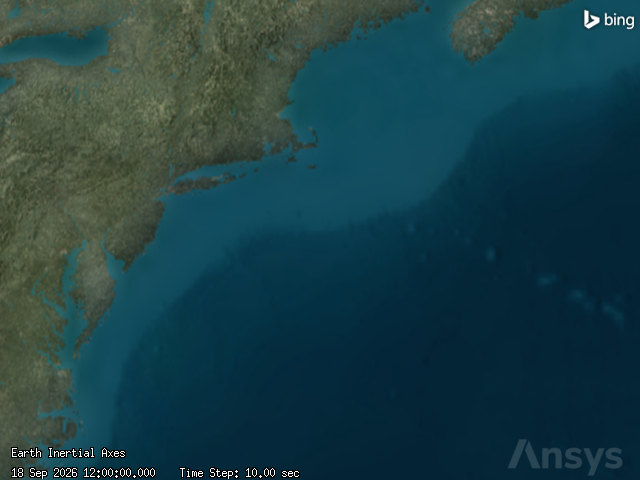

In [4]:
globe_plotter.show()

In [5]:
globe_plotter.camera.direction

[0.280370780507805, -0.803352559784524, -0.5253730961184605]

## Set the scenario time period

The eclipse is visible from Spain during the late afternoon of $12$ August $2026$. Set the scenario time period to a window of $1$ hour and $45$ minutes containing the event, and rewind the scenario so that the graphics match the start and stop times of the scenario:

In [6]:
scenario = root.current_scenario
scenario.set_time_period("12 Aug 2026 17:00:00.000", "12 Aug 2026 18:45:00.000")
root.rewind()

## Insert the asset satellite

A coverage definition always requires at least one asset. Because the analysis is driven by the lighting constraints and not by the visibility of a spacecraft, the asset must be an object that every point of Spain can see during the whole scenario. A geostationary satellite placed over the Greenwich meridian satisfies this requirement.

First, insert the satellite:

In [7]:
from ansys.stk.core.stkobjects import STKObjectType


asset_satellite = scenario.children.new(STKObjectType.SATELLITE, "Asset_Sat")

Then, set the propagator to two-body, which is accurate enough for an asset that only needs to remain in view:

In [8]:
from ansys.stk.core.stkobjects import PropagatorType


asset_satellite.set_propagator_type(PropagatorType.TWO_BODY)
propagator = asset_satellite.propagator

Retrieve the initial state of the propagator as a set of classical orbital elements:

In [9]:
from ansys.stk.core.stkutil import OrbitStateType


orbit = propagator.initial_state.representation.convert_to(OrbitStateType.CLASSICAL)

A geostationary orbit is a circular equatorial orbit with a semi-major axis of $42164.17$ km. Set the ``size_shape_type`` property to semi-major axis and eccentricity:

In [10]:
from ansys.stk.core.stkobjects import ClassicalSizeShape


orbit.size_shape_type = ClassicalSizeShape.SEMIMAJOR_AXIS
orbit.size_shape.semi_major_axis = 42164.17
orbit.size_shape.eccentricity = 0

Set the inclination and the argument of perigee to $0^\circ$ so that the orbit lies on the equatorial plane:

In [11]:
orbit.orientation.inclination = 0
orbit.orientation.argument_of_periapsis = 0

The subsatellite point is controlled with the longitude of the ascending node. Set the ascending node type to longitude and place the satellite over $-3.7^\circ$, roughly the meridian of Madrid:

In [12]:
from ansys.stk.core.stkobjects import OrientationAscNode


orbit.orientation.ascending_node_type = OrientationAscNode.LONGITUDE_ASCENDING_NODE
orbit.orientation.ascending_node.value = -3.7

Finally, set the location type to true anomaly with a value of $0^\circ$:

In [13]:
from ansys.stk.core.stkobjects import ClassicalLocation


orbit.location_type = ClassicalLocation.TRUE_ANOMALY
orbit.location.value = 0

Assign the orbit as the initial state representation of the propagator, and propagate the satellite:

In [14]:
propagator.initial_state.representation.assign(orbit)
propagator.propagate()

## Insert the constraint place

The lighting conditions of the eclipse are modeled with a place object. This object is not analyzed on its own: it is used as a template whose access constraints are replicated on every point of the coverage grid.

First, insert the place and locate it in the east of Spain using geodetic coordinates:

In [15]:
eclipse_constraints = scenario.children.new(STKObjectType.PLACE, "Eclipse_Constraints")
eclipse_constraints.position.assign_geodetic(39.8587, -0.0706, 0)

A location experiences a total eclipse when it is inside the umbra, that is, the darkest part of the shadow cast by the Moon. Add a lighting access constraint to the place:

In [16]:
from ansys.stk.core.stkobjects import AccessConstraintType


lighting_constraint = eclipse_constraints.access_constraints.add_constraint(
    AccessConstraintType.LIGHTING
)

Then, restrict the lighting condition to umbra:

In [17]:
from ansys.stk.core.stkobjects import ConstraintLighting


lighting_constraint.condition = ConstraintLighting.UMBRA

By default, STK only accounts for the shadow cast by the central body. Add a central body obstruction constraint so that the Moon is also considered when the lighting conditions are evaluated:

In [18]:
central_body_obstruction = eclipse_constraints.access_constraints.add_constraint(
    AccessConstraintType.CENTRAL_BODY_OBSTRUCTION
)

Assign the Sun and the Moon to the list of obstructing central bodies. The Sun is assigned by default, so only the Moon needs to be added:

In [19]:
for central_body in ["Sun", "Moon"]:
    if not central_body_obstruction.is_obstruction_assigned(central_body):
        central_body_obstruction.add_obstruction(central_body)

In [20]:
central_body_obstruction.assigned_obstructions

['Sun', 'Moon']

With these two constraints, the place object only has access to the asset satellite while the Moon completely blocks the solar disk.

## Insert the coverage definition

The coverage definition discretizes Spain into a grid of points. Each of these points inherits the lighting constraints of the place object, so the accesses computed between the grid and the asset satellite represent the totality intervals.

First, insert the coverage definition:

In [21]:
spain_coverage = scenario.children.new(
    STKObjectType.COVERAGE_DEFINITION, "Spain_Coverage"
)

Because many properties are modified before computing the accesses, disable the automatic recomputation to avoid unnecessary calculations:

In [22]:
spain_coverage.advanced.recompute_automatically = False

### Restrict the analysis interval to the totality window

The lighting constraint of the place object reports umbra whenever the solar disk is completely blocked, regardless of which body is responsible for it. Over Spain, the Moon casts its umbra between $18{:}26$ and $18{:}35$ UTC, but shortly afterwards the Sun sets on the eastern edge of the country and the Earth itself starts to cast its own umbra. Both events satisfy the constraint, so nightfall would be counted as a second, much longer eclipse in the easternmost regions.

Avoid this by restricting the analysis interval of the coverage definition to a window that contains the totality but excludes the sunset:

In [23]:
spain_coverage.interval.analysis_interval.set_start_and_stop_times(
    "12 Aug 2026 17:00:00.000", "12 Aug 2026 18:35:00.000"
)

### Bound the grid with the Spanish borders

The grid is bounded by the borders of Spain, which are available as an ArcView shapefile shipped with STK. First, set the bounds type to custom regions:

In [24]:
from ansys.stk.core.stkobjects import CoverageBounds


spain_coverage.grid.bounds_type = CoverageBounds.CUSTOM_REGIONS

Then, locate the shapefile inside the STK installation directory:

In [25]:
import os
from pathlib import Path


TOTALITY_THRESHOLD_SECONDS = 10


def resolve_spain_shapefile() -> Path:
    """Return the Spain shapefile path from the local STK installation."""
    if os.name == "nt":
        stk_install_dir = Path(r"C:\Program Files\AGI\STK_ODTK 13")
    else:
        stk_install_dir_env = os.environ.get("STK_INSTALL_DIR")
        if not stk_install_dir_env:
            raise RuntimeError(
                "STK_INSTALL_DIR is not set. Set it to your STK installation directory."
            )
        stk_install_dir = Path(stk_install_dir_env)

    if not stk_install_dir.exists():
        raise FileNotFoundError(
            f"STK installation directory not found: {stk_install_dir}"
        )

    shapefile = (
        stk_install_dir / "Data" / "Shapefiles" / "Countries" / "Spain" / "Spain.shp"
    )
    if not shapefile.exists():
        raise FileNotFoundError(f"Spain shapefile not found: {shapefile}")

    return shapefile


spain_shapefile = resolve_spain_shapefile()

Add the shapefile to the region files of the grid:

In [26]:
spain_coverage.grid.bounds.region_files.add(str(spain_shapefile))

### Set the grid resolution

The grid point granularity presents a trade-off between computational workload and accuracy of the results. Because the path of totality is only a few hundred kilometers wide, a fine resolution of $0.025^\circ$ in latitude and longitude, roughly $2.8$ km, is used to resolve the edges of the band and the location of the longest totality accurately.

First, set the resolution type to latitude/longitude:

In [27]:
from ansys.stk.core.stkobjects import CoverageResolution


spain_coverage.grid.resolution_type = CoverageResolution.RESOLUTION_LATITUDE_LONGITUDE

Then, set the resolution value:

In [28]:
spain_coverage.grid.resolution.latitude_longitude = 0.025

### Seed the grid with the constraint place

The grid points must behave like the place object previously inserted. Set the reference constraint class of the point definition to place:

In [29]:
from ansys.stk.core.stkobjects import CoverageGridClass


spain_coverage.point_definition.grid_class = CoverageGridClass.PLACE

Then, configure the point definition to use an object instance as the grid seed:

In [30]:
spain_coverage.point_definition.use_grid_seed = True

Finally, set the constraint place as the seed object. Every grid point now carries the umbra lighting constraint:

In [31]:
spain_coverage.point_definition.seed_instance = eclipse_constraints.path

## Compute coverage

Assign the asset satellite to the coverage definition:

In [32]:
spain_coverage.asset_list.add(asset_satellite.path)

The grid itself is not relevant for the analysis, so hide the region boundary and the grid points to keep the 3D graphics window clean:

In [33]:
spain_coverage.graphics.static.show_region = False
spain_coverage.graphics.static.show_points = False

Then, compute the accesses between the grid points and the asset. Only the points that are inside the umbra of the Moon at some instant of the scenario report an access:

In [34]:
spain_coverage.compute_accesses()

## Insert an access duration Figure of Merit

The duration of the totality at every grid point is the duration of the access computed in the previous step. An access duration Figure of Merit quantifies this magnitude over the whole grid.

First, insert the Figure of Merit as a child of the coverage definition:

In [35]:
eclipse_path = spain_coverage.children.new(
    STKObjectType.FIGURE_OF_MERIT, "Eclipse_Path"
)

Then, set its definition type to access duration:

In [36]:
from ansys.stk.core.stkobjects import FigureOfMeritDefinitionType


eclipse_path.set_definition_type(FigureOfMeritDefinitionType.ACCESS_DURATION)
definition = eclipse_path.definition

Compute the average of the access durations at every grid point. Since a given location can only experience one totality interval, the average is the duration of the totality itself:

In [37]:
from ansys.stk.core.stkobjects import FigureOfMeritCompute


definition.set_compute_type(FigureOfMeritCompute.AVERAGE)

Finally, enable the satisfaction criterion so that only the points experiencing more than $10$ seconds of totality are highlighted:

In [38]:
from ansys.stk.core.stkobjects import FigureOfMeritSatisfactionType


definition.satisfaction.enable_satisfaction = True
definition.satisfaction.satisfaction_type = FigureOfMeritSatisfactionType.GREATER_THAN
definition.satisfaction.satisfaction_threshold = TOTALITY_THRESHOLD_SECONDS

## Draw the contour map of the duration time

The static graphics of the Figure of Merit draw the contour map of the duration of the totality directly on the globe. First, enable the graphics and fill the grid points:

In [39]:
eclipse_path.graphics.show_graphics = True
eclipse_path.graphics.static.show_graphics = True
eclipse_path.graphics.static.fill_points = True
eclipse_path.graphics.static.fill_translucency = 0

Then, enable the contours and interpolate the color smoothly between grid points:

In [40]:
from ansys.stk.core.stkobjects import FigureOfMeritGraphics2DContourType


contours = eclipse_path.graphics.static.contours
contours.show_graphics = True
contours.contour_type = FigureOfMeritGraphics2DContourType.SMOOTH_FILL
contours.show_contour_lines = True

Add contour levels from $10$ to $120$ seconds every $10$ seconds:

In [41]:
contours.level_attributes.remove_all()
contours.level_attributes.add_level_range(10, 120, 10)

Assign the colors of the levels with a color ramp going from green, for the shortest totalities, to red, for the longest ones:

In [42]:
from ansys.stk.core.stkobjects import FigureOfMeritGraphics2DColorMethod
from ansys.stk.core.utilities.colors import Color


contours.color_method = FigureOfMeritGraphics2DColorMethod.COLOR_RAMP
contours.ramp_color.start_color = Color.from_rgb(143, 188, 143)
contours.ramp_color.end_color = Color.from_rgb(255, 128, 128)

Draw the legend of the contour levels on the 3D graphics window so that the colors can be read as durations:

In [43]:
legend = contours.legend
legend.text_options.title = "Length of eclipse (seconds)"
legend.text_options.number_of_decimal_digits = 0
legend.range_color_options.color_square_width = 40
legend.graphics_3d_window.show_on_map = True
legend.graphics_3d_window.translucency = 40

The constraint place is only a template for the grid points, so hide its graphics to avoid cluttering the map:

In [44]:
eclipse_constraints.graphics.show_graphics = False

Finally, look at the contour map from above. Point the camera to the Iberian Peninsula by expressing its position in the Earth fixed axes:

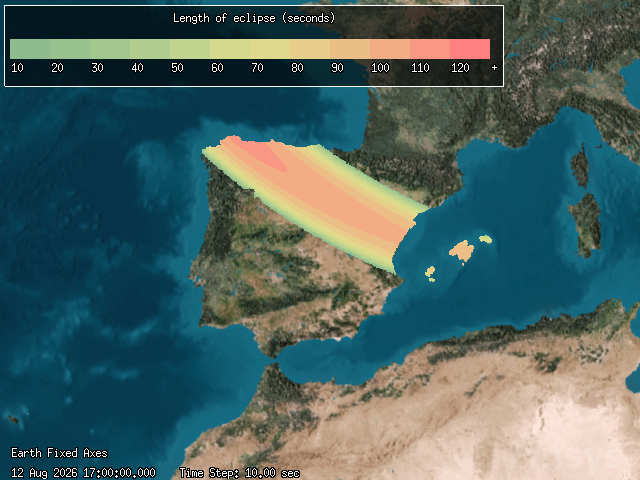

In [45]:
earth_fixed_axes = root.analysis_workbench_components_root.well_known_axes.earth.fixed

globe_plotter.camera.view_central_body("Earth", earth_fixed_axes)
globe_plotter.camera.position = [7150, -440, 6010]
globe_plotter.show()

The contour map shows the path of totality entering Spain through Galicia and Asturias, crossing Castilla y León, Aragón, and the Comunidad Valenciana, and leaving the country through the Balearic Islands. The totality lasts the longest on the northwestern coast, where the Sun is still around $8^\circ$ above the horizon, and it becomes progressively shorter towards the southeast, where the eclipse takes place almost at sunset. It also vanishes towards the edges of the band, where only a partial eclipse is visible.

## Analyze the results

The Value By Point data provider reports the value of the Figure of Merit, in this case the duration of the totality in seconds, at every grid point. Convert it to a pandas ``dataframe``:

In [46]:
value_by_point_df = (
    eclipse_path.data_providers.item("Value By Point")
    .execute()
    .data_sets.to_pandas_dataframe()
)

In [47]:
value_by_point_df = value_by_point_df.astype(
    {"latitude": float, "longitude": float, "fom value": float}
)

STK reports longitudes in the $[0, 360)^\circ$ range. Wrap them into the $[-180, 180)^\circ$ range so that the Spanish territory is contiguous:

In [48]:
value_by_point_df["longitude"] = (value_by_point_df["longitude"] + 180) % 360 - 180

In [49]:
value_by_point_df.head()

,latitude,longitude,altitude,fom value,point number,altitude above msl,utm zone,utm easting,utm northing,mgrs cell
0,27.654701,-17.990092,0.0,0.0,4,-0.03717688587802919,28R,204.99805205925682,3062.5276914810497,28RBR0499862528
1,27.679626,-18.018401,0.0,0.0,5,-0.03722565482886492,27R,794.0968128749558,3065.270441229525,27RYL9409765270
2,27.679626,-17.990092,0.0,0.0,6,-0.03726305230598784,28R,205.06506863882777,3065.2907488753585,28RBR0506565291
3,27.704550,-18.131635,0.0,0.0,7,-0.037084593160687976,27R,782.8579159138226,3067.7681029610335,27RYL8285867768
4,27.704550,-18.103326,0.0,0.0,8,-0.037140696013489224,27R,785.6508596602923,3067.833484344805,27RYL8565167833


Only a fraction of the grid points lies inside the path of totality. Keep the points experiencing a totality longer than the satisfaction threshold:

In [50]:
totality_df = value_by_point_df[
    value_by_point_df["fom value"] > TOTALITY_THRESHOLD_SECONDS
]

In [51]:
print(f"Grid points analyzed: {len(value_by_point_df)}")
print(f"Grid points inside the path of totality: {len(totality_df)}")

Grid points analyzed: 65746
Grid points inside the path of totality: 27476


The longest totality of the eclipse over Spain takes place at:

In [52]:
if totality_df.empty:
    raise RuntimeError("No grid points satisfy the totality duration threshold.")

In [53]:
longest_totality = totality_df.loc[totality_df["fom value"].idxmax()]

In [54]:
print(f"Latitude: {longest_totality['latitude']:.2f} deg")
print(f"Longitude: {longest_totality['longitude']:.2f} deg")
print(f"Duration: {longest_totality['fom value']:.1f} s")

Latitude: 43.68 deg
Longitude: -7.39 deg
Duration: 113.0 s


This location lies on the northwestern coast of Spain, between Galicia and Asturias, which is consistent with the maximum duration published by the Instituto Geográfico Nacional for this eclipse.

## Examine the lighting times of a viewing location

The contour map identifies the regions where the eclipse is total, but a specific viewing location may also be of interest. Insert a place object at the venue of the eclipse observation, for instance the city of Burgos:

In [55]:
viewing_location = scenario.children.new(STKObjectType.PLACE, "Viewing_Location")
viewing_location.position.assign_geodetic(42.3439, -3.6969, 0)

This place is only used to generate a report, so hide its graphics to keep the contour map clean:

In [56]:
viewing_location.graphics.show_graphics = False

The Lighting Times data provider reports the intervals of sunlight, penumbra, and umbra seen from that location. The penumbra intervals correspond to the partial eclipse, whereas the umbra intervals correspond to the total eclipse:

In [57]:
lighting_times_df = (
    viewing_location.data_providers.item("Lighting Times")
    .group.item("Umbra")
    .execute(scenario.start_time, scenario.stop_time)
    .data_sets.to_pandas_dataframe()
)

In [58]:
lighting_times_df

,start time,stop time,duration,obstruction
0,12 Aug 2026 18:28:58.763066002,12 Aug 2026 18:30:42.180232657,103.41716665491276,Moon


The report confirms the duration of the totality obtained from the coverage analysis at the selected viewing location.